# 03 - HMM Regime Detection

This notebook trains a Gaussian Hidden Markov Model (HMM) to discover market regimes such as bull, bear, and crisis from the engineered market features.

Input: `../data/processed/features.csv`  
Output: `../data/processed/regime_features.csv`

In [1]:
%pip install hmmlearn scikit-learn

  Using cached hmmlearn-0.3.3-cp311-cp311-win_amd64.whl.metadata (3.1 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached hmmlearn-0.3.3-cp311-cp311-win_amd64.whl (127 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%pip install pandas

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
try:
	import matplotlib.pyplot as plt
except ModuleNotFoundError:
	get_ipython().run_line_magic("pip", "install matplotlib seaborn")
	import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# Import GaussianHMM; if the import fails at runtime, install and retry.
try:
	from hmmlearn.hmm import GaussianHMM
except ModuleNotFoundError:
	# Ensure package is installed in the current kernel and retry import
	get_ipython().run_line_magic("pip", "install hmmlearn scikit-learn")
	from hmmlearn.hmm import GaussianHMM

plt.style.use("seaborn-v0_8-whitegrid")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl (2.4 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl (7.1 MB)
U

## 2. Load Feature Dataset

In [6]:
FEATURE_PATH = Path("../data/processed/features.csv")
OUTPUT_PATH = Path("../data/processed/regime_features.csv")

features = pd.read_csv(FEATURE_PATH, parse_dates=["Date"])
features = features.sort_values(["ticker", "Date"]).reset_index(drop=True)

print(features.shape)
print(features["ticker"].value_counts())
features.head()

(3694, 28)
ticker
^GSPC    1404
^IXIC    1404
^NSEI     886
Name: count, dtype: int64


,Date,ticker,Open,High,Low,Close,Volume,return_1d,log_return_1d,volatility_7d,...,momentum_30d,momentum_60d,drawdown,high_low_range,volume_change,vix_close,vix_return_1d,vix_volatility_30d,target_return_1d,target_direction_1d
0,2010-03-30,^GSPC,1173.750000,1177.829956,1168.920044,1173.270020,4.085000e+09,0.000043,0.000043,0.004552,...,0.071607,0.032336,-0.000767,0.007622,-0.066409,17.129999,-0.026151,0.033997,-0.003273,0
1,2010-03-31,^GSPC,1171.750000,1174.560059,1165.770020,1169.430054,4.484340e+09,-0.003273,-0.003278,0.004594,...,0.063592,0.028396,-0.004037,0.007540,0.097758,17.590000,0.026854,0.034446,0.007414,1
2,2010-04-01,^GSPC,1171.229980,1181.430054,1170.689941,1178.099976,4.006870e+09,0.007414,0.007386,0.004654,...,0.064468,0.031891,0.000000,0.009174,-0.106475,17.469999,-0.006822,0.033442,0.007928,1
3,2010-04-05,^GSPC,1178.709961,1187.729980,1178.709961,1187.439941,3.881620e+09,0.007928,0.007897,0.004543,...,0.070566,0.037084,0.000000,0.007652,-0.031259,17.020000,-0.025758,0.033352,0.001684,1
4,2010-04-06,^GSPC,1186.010010,1191.800049,1182.770020,1189.439941,4.086180e+09,0.001684,0.001683,0.004200,...,0.073492,0.037019,0.000000,0.007635,0.052700,16.230000,-0.046416,0.034203,-0.005877,0


## 3. Select Asset And HMM Features

Start with NIFTY 50 (`^NSEI`). Later, you can repeat the same process for S&P 500 and NASDAQ.

In [9]:
PRIMARY_TICKER = "^GSPC"

print("Available tickers:")
print(features["ticker"].value_counts())

hmm_feature_cols = [
    "return_1d",
    "volatility_30d",
    "momentum_30d",
    "ma_50_ratio",
    "ma_200_ratio",
    "drawdown",
    "vix_close",
]

asset_df = features[features["ticker"] == PRIMARY_TICKER].copy()

print("Rows before cleaning:", len(asset_df))
print("Missing values:")
print(asset_df[hmm_feature_cols].isna().sum())

asset_df = asset_df.sort_values("Date").copy()

# Fill VIX gaps caused by market holiday/calendar mismatch
asset_df["vix_close"] = asset_df["vix_close"].ffill().bfill()

asset_df = asset_df.dropna(subset=hmm_feature_cols).reset_index(drop=True)

print("Selected ticker:", PRIMARY_TICKER)
print("Rows after cleaning:", len(asset_df))

asset_df[["Date", "ticker", "Close"] + hmm_feature_cols].head()

Available tickers:
ticker
^GSPC    1404
^IXIC    1404
^NSEI     886
Name: count, dtype: int64
Rows before cleaning: 1404
Missing values:
return_1d            0
volatility_30d       0
momentum_30d         0
ma_50_ratio        781
ma_200_ratio      1404
drawdown             0
vix_close            0
dtype: int64
Selected ticker: ^GSPC
Rows after cleaning: 0


,Date,ticker,Close,return_1d,volatility_30d,momentum_30d,ma_50_ratio,ma_200_ratio,drawdown,vix_close


## 4. Scale Features

HMMs are sensitive to feature scale, so we standardize all model inputs.

In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(asset_df[hmm_feature_cols])

print("Training matrix shape:", X.shape)

ValueError: Found array with 0 sample(s) (shape=(0, 7)) while a minimum of 1 is required by StandardScaler.

In [13]:
PRIMARY_TICKER = "^GSPC"

hmm_feature_cols = [
    "return_1d",
    "volatility_30d",
    "momentum_30d",
    "ma_50_ratio",
    "drawdown",
    "vix_close",
]

asset_df = features[features["ticker"] == PRIMARY_TICKER].copy()
asset_df = asset_df.sort_values("Date").reset_index(drop=True)

asset_df["vix_close"] = asset_df["vix_close"].ffill().bfill()

print("Rows before cleaning:", len(asset_df))
print("Missing values before drop:")
print(asset_df[hmm_feature_cols].isna().sum())

asset_df = asset_df.dropna(subset=hmm_feature_cols).reset_index(drop=True)

print("\nSelected ticker:", PRIMARY_TICKER)
print("Rows after cleaning:", len(asset_df))

if len(asset_df) == 0:
    raise ValueError("asset_df is empty. Remove more columns from hmm_feature_cols.")

asset_df[["Date", "ticker", "Close"] + hmm_feature_cols].head()

Rows before cleaning: 1404
Missing values before drop:
return_1d           0
volatility_30d      0
momentum_30d        0
ma_50_ratio       781
drawdown            0
vix_close           0
dtype: int64

Selected ticker: ^GSPC
Rows after cleaning: 623


,Date,ticker,Close,return_1d,volatility_30d,momentum_30d,ma_50_ratio,drawdown,vix_close
0,2010-04-27,^GSPC,1183.709961,-0.023382,0.007319,0.028857,0.020765,-0.027578,22.809999
1,2010-04-28,^GSPC,1191.359985,0.006463,0.007280,0.027513,0.025655,-0.021293,21.080000
2,2010-04-29,^GSPC,1206.780029,0.012943,0.007556,0.034788,0.037015,-0.008626,18.440001
3,2010-04-30,^GSPC,1186.689941,-0.016648,0.008225,0.017893,0.018352,-0.025130,22.049999
4,2010-05-03,^GSPC,1202.260010,0.013121,0.008458,0.036520,0.030068,-0.012339,20.190001


In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(asset_df[hmm_feature_cols])

print("Training matrix shape:", X.shape)

Training matrix shape: (623, 6)


## 5. Train Gaussian HMM

We use 3 hidden states as a first version:

- Bull regime
- Bear regime
- Crisis / high-volatility regime

In [15]:
N_REGIMES = 3

hmm_model = GaussianHMM(
    n_components=N_REGIMES,
    covariance_type="full",
    n_iter=1000,
    random_state=42,
)

hmm_model.fit(X)

asset_df["regime"] = hmm_model.predict(X)
regime_probabilities = hmm_model.predict_proba(X)

for i in range(N_REGIMES):
    asset_df[f"regime_{i}_prob"] = regime_probabilities[:, i]

asset_df[["Date", "ticker", "Close", "regime", "regime_0_prob", "regime_1_prob", "regime_2_prob"]].head()

,Date,ticker,Close,regime,regime_0_prob,regime_1_prob,regime_2_prob
0,2010-04-27,^GSPC,1183.709961,1,5.500702e-12,1.000000,1.553645e-11
1,2010-04-28,^GSPC,1191.359985,0,9.833277e-01,0.016623,4.970221e-05
2,2010-04-29,^GSPC,1206.780029,0,9.994668e-01,0.000531,1.791272e-06
3,2010-04-30,^GSPC,1186.689941,0,9.998941e-01,0.000065,4.078930e-05
4,2010-05-03,^GSPC,1202.260010,0,9.986716e-01,0.000053,1.275341e-03


## 6. Understand And Label Regimes

HMM state numbers are arbitrary. This cell summarizes each state so we can map them to human labels.

In [16]:
regime_summary = (
    asset_df
    .groupby("regime")
    .agg(
        observations=("regime", "size"),
        avg_daily_return=("return_1d", "mean"),
        annualized_return=("return_1d", lambda x: x.mean() * 252),
        annualized_volatility=("return_1d", lambda x: x.std() * np.sqrt(252)),
        avg_momentum_30d=("momentum_30d", "mean"),
        avg_drawdown=("drawdown", "mean"),
        worst_drawdown=("drawdown", "min"),
        avg_vix=("vix_close", "mean"),
    )
    .sort_index()
)

regime_summary

,observations,avg_daily_return,annualized_return,annualized_volatility,avg_momentum_30d,avg_drawdown,worst_drawdown,avg_vix
regime,,,,,,,,
0,412,0.000237,0.059630,0.112719,0.018022,-0.014613,-0.062282,15.315607
1,118,0.000949,0.239130,0.191697,0.075190,-0.095237,-0.177210,23.779322
2,93,-0.000260,-0.065461,0.256518,-0.040392,-0.099125,-0.186753,26.606129


In [17]:
def label_regimes(summary):
    """
    Simple rule-based labels:
    - Crisis: highest volatility, unless another state has much worse drawdown and negative return.
    - Bull: best annualized return among remaining states.
    - Bear: remaining state.
    """
    summary = summary.copy()

    crisis_state = summary["annualized_volatility"].idxmax()

    remaining = [state for state in summary.index if state != crisis_state]
    bull_state = summary.loc[remaining, "annualized_return"].idxmax()

    bear_state = [state for state in summary.index if state not in [crisis_state, bull_state]][0]

    return {
        bull_state: "Bull",
        bear_state: "Bear",
        crisis_state: "Crisis",
    }

regime_label_map = label_regimes(regime_summary)
asset_df["regime_label"] = asset_df["regime"].map(regime_label_map)

print(regime_label_map)
asset_df[["Date", "Close", "regime", "regime_label"]].head()

{np.int64(1): 'Bull', 0: 'Bear', np.int64(2): 'Crisis'}


,Date,Close,regime,regime_label
0,2010-04-27,1183.709961,1,Bull
1,2010-04-28,1191.359985,0,Bear
2,2010-04-29,1206.780029,0,Bear
3,2010-04-30,1186.689941,0,Bear
4,2010-05-03,1202.260010,0,Bear


## 7. Visualize Regimes On Price Chart

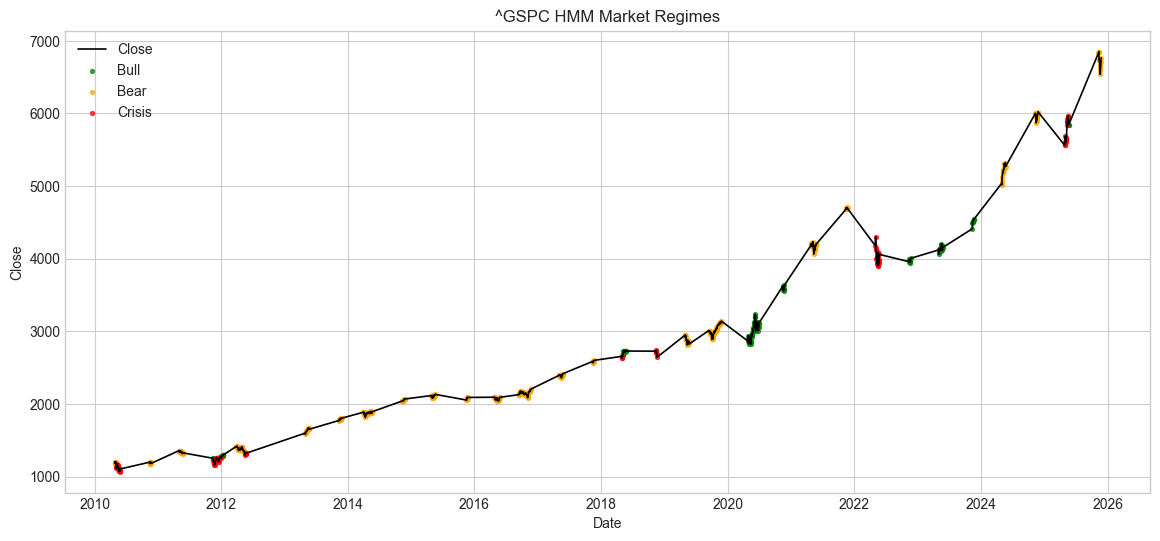

In [18]:
colors = {
    "Bull": "green",
    "Bear": "orange",
    "Crisis": "red",
}

plt.figure(figsize=(14, 6))
plt.plot(asset_df["Date"], asset_df["Close"], color="black", linewidth=1.2, label="Close")

for label, color in colors.items():
    temp = asset_df[asset_df["regime_label"] == label]
    plt.scatter(temp["Date"], temp["Close"], s=8, color=color, label=label, alpha=0.7)

plt.title(f"{PRIMARY_TICKER} HMM Market Regimes")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.show()

## 8. Regime Timeline

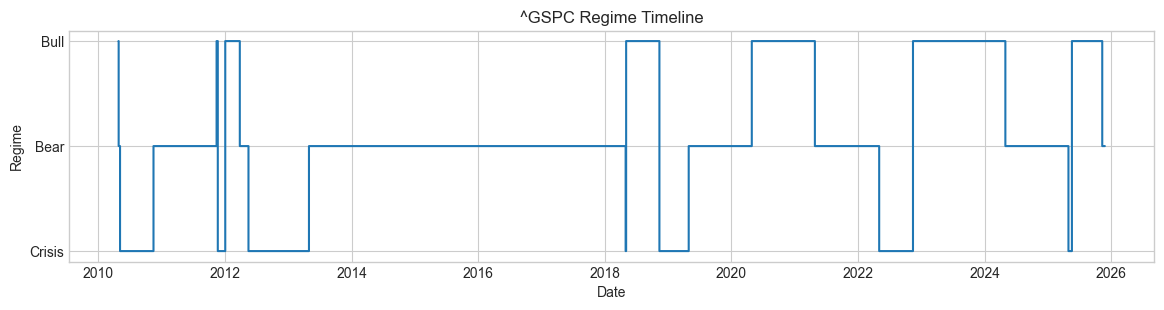

In [19]:
regime_numeric = asset_df["regime_label"].map({"Bull": 2, "Bear": 1, "Crisis": 0})

plt.figure(figsize=(14, 3))
plt.plot(asset_df["Date"], regime_numeric, drawstyle="steps-post")
plt.yticks([0, 1, 2], ["Crisis", "Bear", "Bull"])
plt.title(f"{PRIMARY_TICKER} Regime Timeline")
plt.xlabel("Date")
plt.ylabel("Regime")
plt.show()

## 9. Save Regime Dataset

This output becomes useful for the next notebook: Mixture of Experts.

In [20]:
regime_output_cols = [
    "Date",
    "ticker",
    "Close",
    "return_1d",
    "volatility_30d",
    "momentum_30d",
    "ma_50_ratio",
    "ma_200_ratio",
    "drawdown",
    "vix_close",
    "target_return_1d",
    "target_direction_1d",
    "regime",
    "regime_label",
    "regime_0_prob",
    "regime_1_prob",
    "regime_2_prob",
]

regime_dataset = asset_df[regime_output_cols].copy()
regime_dataset.to_csv(OUTPUT_PATH, index=False)

print("Saved regime dataset to:", OUTPUT_PATH)
print(regime_dataset.shape)
regime_dataset.head()

Saved regime dataset to: ..\data\processed\regime_features.csv
(623, 17)


,Date,ticker,Close,return_1d,volatility_30d,momentum_30d,ma_50_ratio,ma_200_ratio,drawdown,vix_close,target_return_1d,target_direction_1d,regime,regime_label,regime_0_prob,regime_1_prob,regime_2_prob
0,2010-04-27,^GSPC,1183.709961,-0.023382,0.007319,0.028857,0.020765,NaN,-0.027578,22.809999,0.006463,1,1,Bull,5.500702e-12,1.000000,1.553645e-11
1,2010-04-28,^GSPC,1191.359985,0.006463,0.007280,0.027513,0.025655,NaN,-0.021293,21.080000,0.012943,1,0,Bear,9.833277e-01,0.016623,4.970221e-05
2,2010-04-29,^GSPC,1206.780029,0.012943,0.007556,0.034788,0.037015,NaN,-0.008626,18.440001,-0.016648,0,0,Bear,9.994668e-01,0.000531,1.791272e-06
3,2010-04-30,^GSPC,1186.689941,-0.016648,0.008225,0.017893,0.018352,NaN,-0.025130,22.049999,0.013121,1,0,Bear,9.998941e-01,0.000065,4.078930e-05
4,2010-05-03,^GSPC,1202.260010,0.013121,0.008458,0.036520,0.030068,NaN,-0.012339,20.190001,-0.023838,0,0,Bear,9.986716e-01,0.000053,1.275341e-03


## 10. Optional: Train Regimes For Every Asset

This creates HMM regimes separately for every ticker in your feature dataset. Use this when you want a broader dataset for regime-aware modeling.

In [21]:
def fit_hmm_for_ticker(df, ticker, feature_cols, n_regimes=3):
    temp = df[df["ticker"] == ticker].copy()
    temp = temp.dropna(subset=feature_cols).reset_index(drop=True)

    if len(temp) < 300:
        print(f"Skipping {ticker}: not enough rows")
        return None

    X_temp = StandardScaler().fit_transform(temp[feature_cols])

    model = GaussianHMM(
        n_components=n_regimes,
        covariance_type="full",
        n_iter=1000,
        random_state=42,
    )
    model.fit(X_temp)

    temp["regime"] = model.predict(X_temp)
    probs = model.predict_proba(X_temp)

    for i in range(n_regimes):
        temp[f"regime_{i}_prob"] = probs[:, i]

    summary = (
        temp
        .groupby("regime")
        .agg(
            observations=("regime", "size"),
            annualized_return=("return_1d", lambda x: x.mean() * 252),
            annualized_volatility=("return_1d", lambda x: x.std() * np.sqrt(252)),
            avg_drawdown=("drawdown", "mean"),
            avg_vix=("vix_close", "mean"),
        )
    )

    labels = label_regimes(summary)
    temp["regime_label"] = temp["regime"].map(labels)

    return temp

all_regime_dfs = []

for ticker in features["ticker"].unique():
    result = fit_hmm_for_ticker(features, ticker, hmm_feature_cols)
    if result is not None:
        all_regime_dfs.append(result)

all_regimes = pd.concat(all_regime_dfs, ignore_index=True)
all_regimes.to_csv("../data/processed/regime_features_all_assets.csv", index=False)

print(all_regimes.shape)
print(all_regimes["ticker"].value_counts())
all_regimes.head()

(1641, 33)
ticker
^GSPC    623
^IXIC    623
^NSEI    395
Name: count, dtype: int64


,Date,ticker,Open,High,Low,Close,Volume,return_1d,log_return_1d,volatility_7d,...,vix_close,vix_return_1d,vix_volatility_30d,target_return_1d,target_direction_1d,regime,regime_0_prob,regime_1_prob,regime_2_prob,regime_label
0,2010-04-27,^GSPC,1209.920044,1211.380005,1181.619995,1183.709961,7.454540e+09,-0.023382,-0.023660,0.010809,...,22.809999,0.305667,0.072695,0.006463,1,1,5.500702e-12,1.000000,1.553645e-11,Bull
1,2010-04-28,^GSPC,1184.589966,1195.050049,1181.810059,1191.359985,6.342310e+09,0.006463,0.006442,0.010996,...,21.080000,-0.075844,0.074230,0.012943,1,0,9.833277e-01,0.016623,4.970221e-05,Bear
2,2010-04-29,^GSPC,1193.300049,1209.359985,1193.300049,1206.780029,6.059410e+09,0.012943,0.012860,0.011771,...,18.440001,-0.125237,0.077605,-0.016648,0,0,9.994668e-01,0.000531,1.791272e-06,Bear
3,2010-04-30,^GSPC,1206.770020,1207.989990,1186.319946,1186.689941,6.048260e+09,-0.016648,-0.016788,0.013373,...,22.049999,0.195770,0.084855,0.013121,1,0,9.998941e-01,0.000065,4.078930e-05,Bear
4,2010-05-03,^GSPC,1188.579956,1205.130005,1188.579956,1202.260010,4.938050e+09,0.013121,0.013035,0.014557,...,20.190001,-0.084354,0.086658,-0.023838,0,0,9.986716e-01,0.000053,1.275341e-03,Bear


## Next Step

After this notebook runs successfully, build `04_mixture_of_experts.ipynb`.

That notebook will compare:

- Baseline single model
- Regime-aware model with separate experts